In [8]:
import pandas as pd
import numpy as np
import faiss
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time
import sys 
from pathlib import Path
import torch

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

from src.models.train import train 

from src import config

In [9]:
config.TRAIN_PARAMS["num_epochs"] = 1
device = "cuda" if torch.cuda.is_available() else "cpu"
lr_range = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e-0]
losses = []
for lr in lr_range:
    print(f"Training with learning rate: {lr}")
    config.TRAIN_PARAMS["transformer_lr"] = lr
    loss_info = train(device)
    losses.append(loss_info["loss"][0])

Training with learning rate: 1e-08
Using device: cuda
DualEncoder initialized in 'encoder-only' mode (without metadata).
No model weights provided. Loaded untrained model with architecture /home/gort/Projects/coffee-rating/models/MiniLM-L6-v2.
Model set to training mode.
Training with encoder only. No head parameters will be updated.
Starting training...
Epoch 1/1 - Using In-Batch Negative Mining


Epoch 1: 100%|██████████| 132/132 [01:11<00:00,  1.84it/s]


Epoch 1 complete. Average loss: 0.1153
Training with learning rate: 1e-07
Using device: cuda
DualEncoder initialized in 'encoder-only' mode (without metadata).
No model weights provided. Loaded untrained model with architecture /home/gort/Projects/coffee-rating/models/MiniLM-L6-v2.
Model set to training mode.
Training with encoder only. No head parameters will be updated.
Starting training...
Epoch 1/1 - Using In-Batch Negative Mining


Epoch 1:   7%|▋         | 9/132 [00:05<01:16,  1.62it/s]


KeyboardInterrupt: 

In [10]:
torch.cuda.empty_cache()

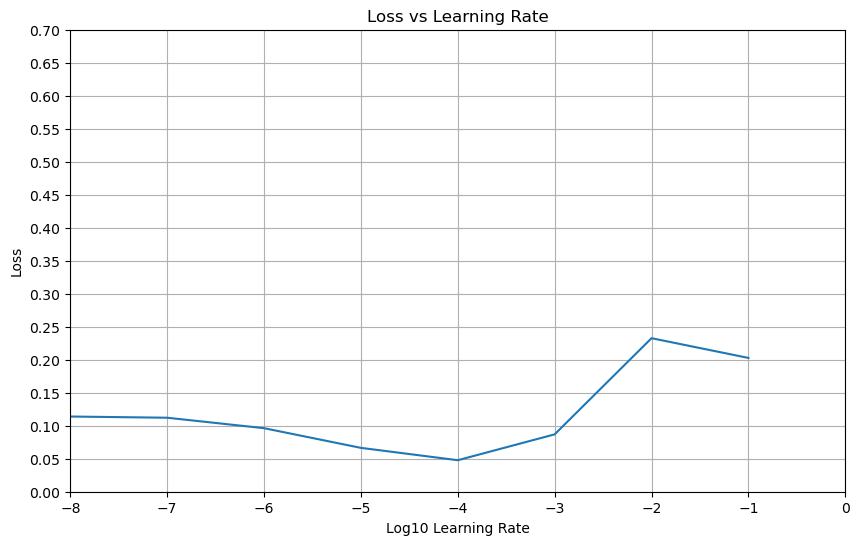

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(np.log10(lr_range), losses)
plt.xlabel("Log10 Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.xlim(-8, 0)
plt.yticks(np.arange(0, max(losses) + 0.5, 0.05))
plt.grid(True)
plt.show();

In [4]:
1e-5

1e-05